# Notebook 3 — GMS, AFK-MC2 và K-means

**Trước:** chạy `01_DataProcessing` → `02_GMM`. **Cài:** `python3 -m pip install -r requirements.txt` (cần `afkmc2`).

Cùng **một** bài toán: K-means (thuật toán **Elkan**) trên toàn bộ ma trận `X` (`R_z`, `F_z`, `M_z`) với **cùng số cụm `k`**. Khác nhau **duy nhất** ở **cách lấy `k` tâm ban đầu** (`init`).

## Bốn cách so sánh

| | Phương án | Tâm khởi tạo |
|---|-----------|----------------|
| **A** | **GMS + AFK-MC2 (sub) + K-means (full)** | Fit GMM → sinh mẫu từ GMM → ánh xạ về điểm thật gần nhất (**GMS**) → AFK-MC2 chỉ trên tập con → các tâm đó làm `init` cho K-means trên **full** |
| **B** | **AFK-MC2 (full) + K-means** | AFK-MC2 chạy trên **toàn bộ** `X` → `init` cho K-means trên full |
| **C** | **K-means++** | Quy tắc k-means++ (trọng số khoảng cách bình phương), `n_init=10` |
| **D** | **K-means (random)** | Tâm ngẫu nhiên, `n_init=10` |

**GMM vs `k`:** số thành phần hỗn hợp trong NB2 (AIC/BIC) **không nhất thiết** bằng `k` cụm marketing. **Package `afkmc2`:** chỉ có `afkmc2(X, k)` — không có bước “AFK lần hai trên full với tâm sẵn”; ta dùng **một lần** K-means full với `init` từ AFK-MC2(sub) như trong bảng A.

## Chọn `k` cho K-means

Notebook quét `k` trong `[K_SEARCH_MIN, K_SEARCH_MAX]`, ghi `data/kmeans_k_selection.csv`, vẽ elbow và Silhouette / Davies–Bouldin. Sau đó gán `N_CLUSTERS` theo `K_SELECTION_MODE`: `fixed` (mặc định 4), `auto_silhouette`, hoặc `auto_davies_bouldin`.

## 1. Import, đường dẫn, hằng số

Chỉnh `K_SELECTION_MODE`, `FIXED_K`, `SAMPLE_RATE`, … ở đây.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture

try:
    import afkmc2.afkmc2 as afk_seed
except ImportError as e:
    raise ImportError("Cần: python3 -m pip install afkmc2") from e


def _find_requirements_parent(start: Path) -> Path | None:
    p = start.resolve()
    for _ in range(8):
        if (p / "requirements.txt").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def project_root() -> Path:
    env = os.environ.get("GMS_PROJECT_ROOT", "").strip()
    if env:
        root = Path(env).expanduser().resolve()
        hit = _find_requirements_parent(root)
        if hit is not None:
            return hit
        if (root / "requirements.txt").is_file():
            return root

    candidates: list[Path] = []
    try:
        candidates.append(Path.cwd().resolve())
    except FileNotFoundError:
        pass

    pwd = os.environ.get("PWD", "").strip()
    if pwd:
        try:
            pp = Path(pwd).expanduser().resolve()
            if pp.is_dir():
                candidates.append(pp)
        except OSError:
            pass

    for key in ("JUPYTER_SERVER_ROOT", "VSCODE_CWD"):
        v = os.environ.get(key, "").strip()
        if not v:
            continue
        try:
            pp = Path(v).expanduser().resolve()
            if pp.is_dir():
                candidates.append(pp)
        except OSError:
            pass

    if not candidates:
        home = Path.home()
        try:
            os.chdir(home)
            candidates.append(Path.cwd().resolve())
        except (FileNotFoundError, OSError):
            candidates.append(home.resolve())

    for c in candidates:
        hit = _find_requirements_parent(c)
        if hit is not None:
            try:
                os.chdir(hit)
            except OSError:
                pass
            return hit

    raise FileNotFoundError(
        "Không tìm thấy requirements.txt (tối đa 8 cấp từ cwd). "
        "cwd của kernel có thể đã mất — chạy: import os; os.chdir('/path/to/GMS_AFKMC2') "
        "hoặc đặt biến môi trường GMS_PROJECT_ROOT."
    )


ROOT = project_root()
DATA_PATH = ROOT / "data" / "rfm_customers.csv"
OUT_DIR = ROOT / "data"
MODEL_PATH = ROOT / "models" / "gmm_rfm.joblib"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["R_z", "F_z", "M_z"]
RANDOM_STATE = 42

K_SEARCH_MIN, K_SEARCH_MAX = 2, 10
K_SELECTION_MODE = "fixed"  # "fixed" | "auto_silhouette" | "auto_davies_bouldin"
FIXED_K = 4

SAMPLE_RATE = 0.5

GMM_FALLBACK_N_COMPONENTS = 8
GMM_N_INIT = 5
GMM_MAX_ITER = 200

AFKMC2_CHAIN_LEN = 200
KMEANS_MAX_ITER = 300


def gms_nearest_real_points(
    X_data: np.ndarray,
    gmm: GaussianMixture,
    n_sample: int,
) -> np.ndarray:
    synth, _ = gmm.sample(n_sample)
    idx = [
        int(np.argmin(np.linalg.norm(X_data - s, axis=1)))
        for s in synth
    ]
    return X_data[np.array(idx, dtype=int)]


def load_or_fit_gmm(X_data: np.ndarray) -> GaussianMixture:
    if MODEL_PATH.is_file():
        return joblib.load(MODEL_PATH)["gmm"]
    gmm = GaussianMixture(
        n_components=GMM_FALLBACK_N_COMPONENTS,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=GMM_N_INIT,
        max_iter=GMM_MAX_ITER,
    )
    gmm.fit(X_data)
    return gmm

## 2. Đọc `X`, quét `k`, chọn `N_CLUSTERS`

Mỗi `k`: K-means++ (`n_init=10`) để có SSE, Silhouette, DBI, `n_iter` (chỉ phục vụ chọn `k`, không phải một trong bốn phương án so sánh chính).

X shape: (5878, 3)


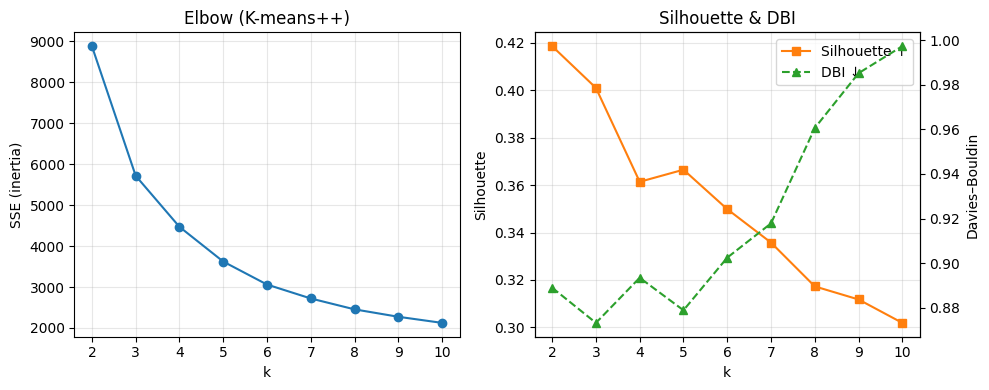

 k  SSE_inertia  silhouette  davies_bouldin  n_iter
 2  8879.753864    0.418630        0.888986       4
 3  5715.503664    0.401026        0.873209       7
 4  4469.006535    0.361398        0.893440      16
 5  3621.429999    0.366502        0.878871      22
 6  3060.503972    0.349856        0.902456      21
 7  2720.481339    0.335744        0.917814      39
 8  2454.747346    0.317264        0.960575      34
 9  2273.723060    0.311744        0.985152      19
10  2124.516865    0.301865        0.997259      21

N_CLUSTERS = 4 (fixed K=4)
→ /Users/kotori/GMS_AFKMC2/data/kmeans_k_selection.csv


In [2]:
rfm = pd.read_csv(DATA_PATH)
miss = [c for c in FEATURE_COLS if c not in rfm.columns]
if miss:
    raise ValueError(f"Thiếu cột {miss} — chạy 01_DataProcessing trước.")

X = rfm[FEATURE_COLS].to_numpy(dtype=float)
print("X shape:", X.shape)

k_hi = min(K_SEARCH_MAX, X.shape[0] - 1)
if k_hi < K_SEARCH_MIN:
    raise ValueError(f"Cần n > k: n={X.shape[0]}")

rows = []
for k in range(K_SEARCH_MIN, k_hi + 1):
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=KMEANS_MAX_ITER,
        random_state=RANDOM_STATE,
        algorithm="elkan",
    )
    labels = km.fit_predict(X)
    rows.append(
        {
            "k": k,
            "SSE_inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "n_iter": km.n_iter_,
        }
    )
k_scan = pd.DataFrame(rows)
k_csv = OUT_DIR / "kmeans_k_selection.csv"
k_scan.to_csv(k_csv, index=False)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))
ax0.plot(k_scan["k"], k_scan["SSE_inertia"], "o-", color="C0")
ax0.set(xlabel="k", ylabel="SSE (inertia)", title="Elbow (K-means++)")
ax0.grid(True, alpha=0.3)
ax1.plot(k_scan["k"], k_scan["silhouette"], "s-", color="C1", label="Silhouette ↑")
ax1b = ax1.twinx()
ax1b.plot(k_scan["k"], k_scan["davies_bouldin"], "^--", color="C2", label="DBI ↓")
ax1.set(xlabel="k", ylabel="Silhouette", title="Silhouette & DBI")
ax1b.set_ylabel("Davies–Bouldin")
ax1.grid(True, alpha=0.3)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="best")
fig.tight_layout()
plt.show()

if K_SELECTION_MODE == "fixed":
    if not (K_SEARCH_MIN <= FIXED_K <= k_hi):
        raise ValueError(f"FIXED_K={FIXED_K} ∉ [{K_SEARCH_MIN}, {k_hi}]")
    N_CLUSTERS = int(FIXED_K)
    reason = f"fixed K={FIXED_K}"
elif K_SELECTION_MODE == "auto_silhouette":
    row = k_scan.loc[k_scan["silhouette"].idxmax()]
    N_CLUSTERS, reason = int(row["k"]), f"max Silhouette @ k={int(row['k'])}"
elif K_SELECTION_MODE == "auto_davies_bouldin":
    row = k_scan.loc[k_scan["davies_bouldin"].idxmin()]
    N_CLUSTERS, reason = int(row["k"]), f"min DBI @ k={int(row['k'])}"
else:
    raise ValueError("K_SELECTION_MODE: fixed | auto_silhouette | auto_davies_bouldin")

print(k_scan.to_string(index=False))
print(f"\nN_CLUSTERS = {N_CLUSTERS} ({reason})\n→ {k_csv.resolve()}")

## 3. Hai mô hình dùng AFK-MC2

- **A:** GMS (GMM → mẫu → điểm thật gần nhất) → AFK-MC2 trên `X_sub` → K-means full.
- **B:** AFK-MC2 trên full `X` → K-means full.

Cả hai đều `n_init=1` vì tâm đã cố định bởi AFK-MC2.

In [3]:
np.random.seed(RANDOM_STATE)

n = X.shape[0]
n_sub = max(N_CLUSTERS, int(round(SAMPLE_RATE * n)))
gmm = load_or_fit_gmm(X)
X_sub = gms_nearest_real_points(X, gmm, n_sub)
print(f"GMS: |X_sub|={len(X_sub)} (~{SAMPLE_RATE}·n), GMM components={gmm.n_components}")

init_sub = afk_seed.afkmc2(X_sub, N_CLUSTERS, m=AFKMC2_CHAIN_LEN)
km_gms_afk = KMeans(
    n_clusters=N_CLUSTERS,
    init=init_sub,
    n_init=1,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
).fit(X)

init_full = afk_seed.afkmc2(X, N_CLUSTERS, m=AFKMC2_CHAIN_LEN)
km_afk_full = KMeans(
    n_clusters=N_CLUSTERS,
    init=init_full,
    n_init=1,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
).fit(X)

print(f"A  GMS+AFK(sub)+K:  SSE={km_gms_afk.inertia_:.4f}  n_iter={km_gms_afk.n_iter_}")
print(f"B  AFK(full)+K:     SSE={km_afk_full.inertia_:.4f}  n_iter={km_afk_full.n_iter_}")

GMS: |X_sub|=2939 (~0.5·n), GMM components=8
A  GMS+AFK(sub)+K:  SSE=4468.9147  n_iter=6
B  AFK(full)+K:     SSE=4785.2520  n_iter=16


## 4. Baselines sklearn (không GMM / AFK)

- **C:** K-means++ — `n_init=10`.
- **D:** Random — `n_init=10`.

In [4]:
km_pp = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=10,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
).fit(X)

km_rand = KMeans(
    n_clusters=N_CLUSTERS,
    init="random",
    n_init=10,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
).fit(X)

print(f"C  K-means++:       SSE={km_pp.inertia_:.4f}  n_iter={km_pp.n_iter_}")
print(f"D  random:          SSE={km_rand.inertia_:.4f}  n_iter={km_rand.n_iter_}")

C  K-means++:       SSE=4469.0065  n_iter=16
D  random:          SSE=4468.9611  n_iter=12


## 5. Bảng metric và xuất CSV

Cùng bốn chỉ số: SSE (inertia), Silhouette, Davies–Bouldin, `n_iter`.

In [5]:
def row_metrics(name: str, model: KMeans) -> dict:
    lab = model.labels_
    return {
        "method": name,
        "SSE_inertia": float(model.inertia_),
        "silhouette": float(silhouette_score(X, lab)),
        "davies_bouldin": float(davies_bouldin_score(X, lab)),
        "n_iter": int(model.n_iter_),
    }


FIT_MODELS = [
    ("GMS + AFK-MC2 (sub) + K-means (full)", km_gms_afk),
    ("AFK-MC2 (full) + K-means", km_afk_full),
    ("K-means++", km_pp),
    ("K-means (random init)", km_rand),
]

metrics_df = pd.DataFrame([row_metrics(n, m) for n, m in FIT_MODELS])
display(metrics_df)

out = rfm.copy()
out["kmeans_gms_afkmc2_pipeline"] = km_gms_afk.labels_
out["kmeans_afkmc2_full"] = km_afk_full.labels_
out["kmeans_pp"] = km_pp.labels_
out["kmeans_random"] = km_rand.labels_

path_rfm = OUT_DIR / "rfm_with_kmeans_clusters.csv"
path_cmp = OUT_DIR / "kmeans_init_comparison.csv"
out.to_csv(path_rfm, index=False)
metrics_df.to_csv(path_cmp, index=False)
print(path_rfm.resolve())
print(path_cmp.resolve())
out.head()

,method,SSE_inertia,silhouette,davies_bouldin,n_iter
0,GMS + AFK-MC2 (sub) + K-means (full),4468.914716,0.361583,0.891984,6
1,AFK-MC2 (full) + K-means,4785.251991,0.384365,0.927945,16
2,K-means++,4469.006535,0.361398,0.893440,16
3,K-means (random init),4468.961106,0.361472,0.892792,12


/Users/kotori/GMS_AFKMC2/data/rfm_with_kmeans_clusters.csv
/Users/kotori/GMS_AFKMC2/data/kmeans_init_comparison.csv


,customer_id,R,F,M,F_log1p,M_log1p,R_z,F_z,M_z,kmeans_gms_afkmc2_pipeline,kmeans_afkmc2_full,kmeans_pp,kmeans_random
0,12346.0,325,12,77556.46,2.564949,11.258774,0.595584,1.254496,3.186625,3,0,3,3
1,12347.0,1,8,5633.32,2.197225,8.636632,-0.952279,0.800166,1.297127,3,0,3,3
2,12348.0,74,5,2019.40,1.791759,7.611051,-0.603532,0.299207,0.558100,1,3,2,0
3,12349.0,18,4,4428.69,1.609438,8.396085,-0.871064,0.073946,1.123790,1,0,2,0
4,12350.0,309,1,334.40,0.693147,5.815324,0.519146,-1.058146,-0.735888,2,2,0,1


## 6. PCA-2D (minh họa)

Chiếu `X` lên 2 PC đầu; **màu = nhãn cụm** (không dùng PCA để phân cụm).

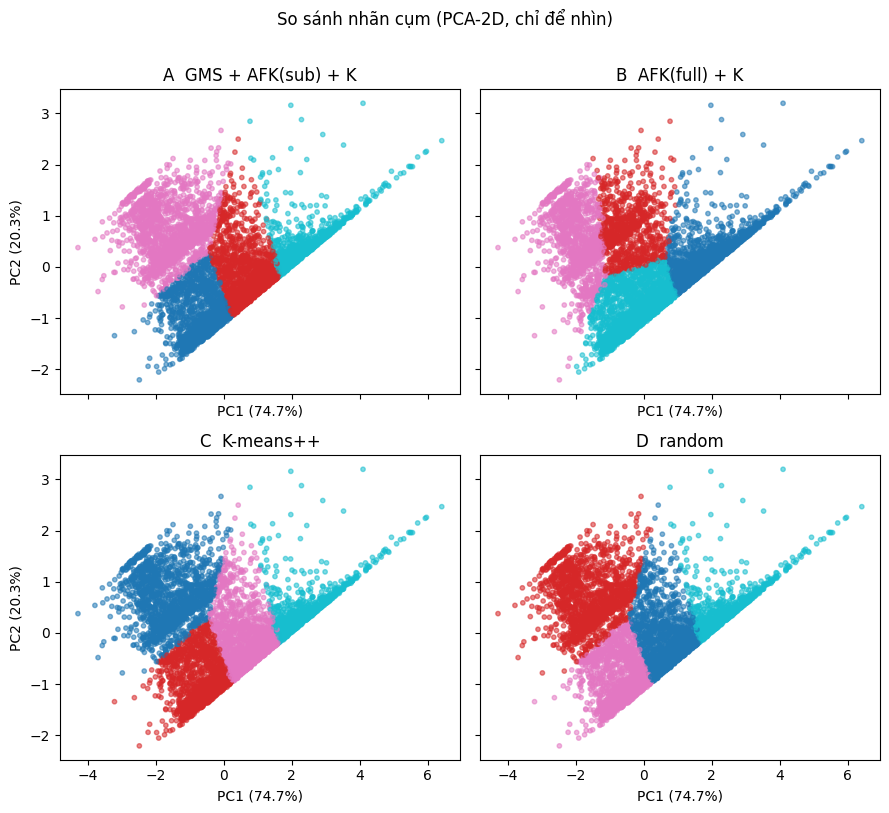

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X)
ev = pca.explained_variance_ratio_

fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
short_titles = [
    "A  GMS + AFK(sub) + K",
    "B  AFK(full) + K",
    "C  K-means++",
    "D  random",
]
for ax, (title, (_, model)) in zip(axes.ravel(), zip(short_titles, FIT_MODELS)):
    ax.scatter(X2[:, 0], X2[:, 1], c=model.labels_, cmap="tab10", s=10, alpha=0.55)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
axes = fig.axes
axes[0].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
fig.suptitle("So sánh nhãn cụm (PCA-2D, chỉ để nhìn)", y=1.01)
fig.tight_layout()
plt.show()